# Version 0.2

# LLM Benchmark on Google Colab T4 GPU

This notebook demonstrates how to:
1. Load a pre-trained LLM model
2. Run inference benchmarks on Google Colab's T4 GPU
3. Measure performance metrics (latency, throughput, memory usage)
4. Visualize the results

The model used is **DistilBERT** - a lightweight version of BERT that's perfect for testing on limited GPU resources like T4.

## 1. Install Required Libraries

In [14]:
# Install required libraries
import subprocess
import sys

# Install transformers and torch
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "datasets"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pandas"])

print("✓ All libraries installed successfully!")

✓ All libraries installed successfully!


## 2. Check GPU and Setup

In [15]:
import torch
import numpy as np
import time
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime

# Check GPU availability
print("GPU Information:")
print(f"  Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"  CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  Current GPU Memory: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print()

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")

GPU Information:
  Device: Tesla T4
  CUDA Available: True
  GPU Memory: 15.64 GB
  Current GPU Memory: 0.28 GB

✓ Using device: cuda


## 3. Load Pretrained LLM Model

We use **DistilBERT** - a lightweight BERT model that works great on T4 GPUs. It's 40% smaller and 60% faster than BERT while retaining 97% of its performance.

In [16]:
# Load DistilBERT tokenizer and model
print("Loading DistilBERT model...")
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Move model to GPU
model = model.to(device)
model.eval()  # Set to evaluation mode

print(f"✓ Model loaded successfully!")
print(f"  Model: {model_name}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

# Get model size
param_size = sum(p.numel() for p in model.parameters()) * 4 / (1024 ** 2)  # 4 bytes per float32
print(f"  Model size: {param_size:.2f} MB")

Loading DistilBERT model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Model loaded successfully!
  Model: distilbert-base-uncased
  Total parameters: 66.96M
  Model size: 255.41 MB


## 4. Load ARC (AI2 Reasoning Challenge) Dataset

The ARC dataset contains science exam questions with 4 multiple-choice answers. It tests reasoning and knowledge across science, physics, chemistry, and biology.

In [ ]:
from datasets import load_dataset

# Load ARC dataset (Easy and Challenge)
print("Loading ARC dataset...")
arc_easy = load_dataset("ai2_arc", "ARC-Easy", split="test", trust_remote_code=True)
arc_challenge = load_dataset("ai2_arc", "ARC-Challenge", split="test", trust_remote_code=True)

# Combine and limit to 60 samples each for T4 GPU (total 120+)
arc_data = []

# Use .select() to properly index dataset
easy_indices = range(min(60, len(arc_easy)))
challenge_indices = range(min(60, len(arc_challenge)))

for idx in easy_indices:
    arc_data.append(arc_easy[idx])

for idx in challenge_indices:
    arc_data.append(arc_challenge[idx])

print(f"✓ Loaded {len(arc_data)} ARC questions (60 Easy + 60 Challenge)")
print(f"\nFirst example:")
print(f"  Question: {arc_data[0]['question']}")
print(f"  Choices: {arc_data[0]['choices']['text']}")
print(f"  Answer: {arc_data[0]['answerKey']}")

# Function to categorize questions based on keywords
def categorize_question(question_text, choices_text=None):
    """Categorize a question into different science domains based on keywords."""
    full_text = question_text.lower()
    if choices_text:
        full_text += " " + " ".join([c.lower() for c in choices_text])
    
    # Physics keywords
    if any(word in full_text for word in ['force', 'motion', 'velocity', 'acceleration', 'gravity', 
                                            'energy', 'speed', 'momentum', 'friction', 'pressure', 
                                            'wave', 'sound', 'light', 'magnet', 'electric', 'charge']):
        return 'Physics'
    
    # Chemistry keywords
    elif any(word in full_text for word in ['atom', 'molecule', 'element', 'compound', 'reaction', 
                                             'chemical', 'acid', 'base', 'salt', 'bond', 'metal', 
                                             'gas', 'liquid', 'solid', 'mixture', 'solution', 'oxidation']):
        return 'Chemistry'
    
    # Biology keywords
    elif any(word in full_text for word in ['organism', 'cell', 'living', 'life', 'species', 'animal', 
                                             'plant', 'gene', 'dna', 'evolution', 'ecosystem', 'food chain', 
                                             'photosynthesis', 'mitochondria', 'protein', 'biological', 
                                             'reproduction', 'mutation', 'adaptation', 'population']):
        return 'Biology'
    
    # Earth Science keywords
    elif any(word in full_text for word in ['earth', 'weather', 'climate', 'rock', 'mineral', 'soil', 
                                             'geology', 'volcano', 'earthquake', 'water', 'ocean', 'atmosphere', 
                                             'wind', 'temperature', 'precipitation', 'fossil', 'erosion']):
        return 'Earth Science'
    
    # Astronomy keywords
    elif any(word in full_text for word in ['star', 'planet', 'moon', 'sun', 'galaxy', 'space', 'orbit', 
                                             'asteroid', 'comet', 'spacecraft', 'universe', 'constellation', 
                                             'solar', 'astronomy', 'celestial']):
        return 'Astronomy'
    
    # General Science (default)
    else:
        return 'General Science'

# Prepare data in format suitable for classification
arc_samples = []
for example in arc_data:
    correct_answer_idx = ord(example['answerKey']) - ord('A')  # Convert A,B,C,D to 0,1,2,3
    choices = example['choices']['text']
    
    # Categorize the question
    category = categorize_question(example['question'], choices)

    # Create premise (question + each choice combination)
    for idx, choice in enumerate(choices):
        arc_samples.append({
            'question': example['question'],
            'choice': choice,
            'label': 1 if idx == correct_answer_idx else 0,  # 1 if correct, 0 if not
            'choice_idx': idx,
            'question_id': example['id'],
            'category': category
        })

print(f"\n✓ Prepared {len(arc_samples)} samples for evaluation")
print(f"  Correct answers: {sum(s['label'] for s in arc_samples)}")

# Show category distribution
print(f"\nCategory Distribution:")
category_counts = {}
for sample in arc_samples:
    cat = sample['category']
    category_counts[cat] = category_counts.get(cat, 0) + 1

for category, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {category}: {count} samples")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ai2_arc' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ai2_arc' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading ARC dataset...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ai2_arc' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'ai2_arc' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


✓ Loaded 120 ARC questions (60 Easy + 60 Challenge)

First example:
  Question: Which statement best explains why photosynthesis is the foundation of most food webs?
  Choices: ['Sunlight is the source of energy for nearly all ecosystems.', 'Most ecosystems are found on land instead of in water.', 'Carbon dioxide is more available than other gases.', 'The producers in all ecosystems are plants.']
  Answer: A

✓ Prepared 480 samples for evaluation
  Correct answers: 117


## 5. Run ARC Benchmark

Evaluate the model on ARC questions - measure accuracy and reasoning capability.

In [ ]:
# Evaluate model on ARC dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from collections import defaultdict

print("Running ARC Benchmark...\n")
print("=" * 60)

# Store predictions per question and per category
question_predictions = defaultdict(list)
category_accuracies = defaultdict(lambda: {'correct': 0, 'total': 0})
all_predictions = []
all_labels = []
timings = []

# Tokenize all samples at once for efficiency
question_choice_pairs = [f"{s['question']} {s['choice']}" for s in arc_samples]

print(f"Processing {len(arc_samples)} question-choice pairs...")
print(f"Batch processing with batch size: 8\n")

# Process in batches
batch_size = 8
correct_count = 0
total_count = 0

for batch_idx in range(0, len(arc_samples), batch_size):
    batch_samples = arc_samples[batch_idx:batch_idx + batch_size]
    batch_texts = [f"{s['question']} {s['choice']}" for s in batch_samples]
    
    # Tokenize
    encodings = tokenizer(
        batch_texts,
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    )
    
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    
    # Measure inference time
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    start_time = time.time()
    
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits  # Shape: (batch_size, 2)
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    end_time = time.time()
    timings.append(end_time - start_time)
    
    # Get confidence scores for "correct" label (class 1)
    confidences = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
    
    # Store predictions grouped by question
    for i, sample in enumerate(batch_samples):
        q_id = sample['question_id']
        pred_confidence = confidences[i]
        category = sample['category']
        
        question_predictions[q_id].append({
            'choice_idx': sample['choice_idx'],
            'confidence': pred_confidence,
            'label': sample['label'],
            'category': category
        })

print(f"\n✓ Inference complete!")
print(f"Total inference time: {sum(timings):.2f}s")
print(f"Average time per sample: {(sum(timings) / len(arc_samples) * 1000):.2f}ms")

# Determine best answer per question and calculate accuracy
predictions_per_question = []
labels_per_question = []
per_sample_preds = []
per_sample_labels = []

for q_id, choices in question_predictions.items():
    # Find choice with highest confidence
    best_choice = max(choices, key=lambda x: x['confidence'])
    predicted_correct = best_choice['label']
    category = best_choice['category']
    
    predictions_per_question.append(predicted_correct)
    
    # Find ground truth
    ground_truth = any(c['label'] == 1 for c in choices)
    labels_per_question.append(1 if ground_truth else 0)
    
    # Per-sample collection
    for choice in choices:
        per_sample_preds.append(choice['confidence'] > 0.5)
        per_sample_labels.append(choice['label'])
    
    # Update category statistics
    category_accuracies[category]['total'] += 1
    if predicted_correct == 1:  # If best choice was correct
        category_accuracies[category]['correct'] += 1

# Calculate metrics
accuracy_per_question = accuracy_score(labels_per_question, predictions_per_question)
accuracy_per_choice = accuracy_score(per_sample_labels, per_sample_preds)

print(f"\nAccuracy Metrics:")
print(f"  Per-Question Accuracy: {accuracy_per_question * 100:.2f}%")
print(f"  Per-Choice Accuracy: {accuracy_per_choice * 100:.2f}%")

# Convert defaultdict to regular dict for storage
category_accuracies = dict(category_accuracies)

benchmark_results = {
    'Accuracy (per question)': accuracy_per_question,
    'Accuracy (per choice)': accuracy_per_choice,
    'Total Questions': len(predictions_per_question),
    'Total Samples': len(arc_samples),
    'Avg Inference Time (ms)': (sum(timings) / len(arc_samples)) * 1000,
    'Total Inference Time (s)': sum(timings),
    'Category Accuracies': category_accuracies
}

print("\n✓ Benchmark complete!")

Running ARC Benchmark...

Processing 480 question-choice pairs...
Batch processing with batch size: 8


✓ Inference complete!
Total inference time: 3.42s
Average time per sample: 7.12ms

Accuracy Metrics:
  Per-Question Accuracy: 27.50%
  Per-Choice Accuracy: 24.38%

✓ Benchmark complete!


## 6. Display Results

Show detailed benchmark results including accuracy scores and performance metrics.

In [19]:
# Display detailed results
print("\n" + "=" * 80)
print("ARC BENCHMARK RESULTS (120+ Questions)")
print("=" * 80)

print(f"\nDataset Statistics:")
print(f"  Total Questions: {benchmark_results['Total Questions']}")
print(f"  Total Samples: {benchmark_results['Total Samples']}")
print(f"  Question-Answer Pairs: {len(arc_data)}")

print(f"\nOverall Accuracy Scores:")
print(f"  Per-Question Accuracy: {benchmark_results['Accuracy (per question)'] * 100:.2f}%")
print(f"  Per-Choice Accuracy: {benchmark_results['Accuracy (per choice)'] * 100:.2f}%")

print(f"\nAccuracy by Category:")
print("-" * 80)
print(f"{'Category':<30} {'Accuracy':<15} {'Correct/Total':<20}")
print("-" * 80)

for category, stats in sorted(benchmark_results['Category Accuracies'].items(),
                              key=lambda x: (x[1]['total']/x[1]['total'] if x[1]['total'] > 0 else 0) *
                                           (x[1]['correct']/x[1]['total'] if x[1]['total'] > 0 else 0),
                              reverse=True):
    if stats['total'] > 0:
        cat_acc = (stats['correct'] / stats['total']) * 100
        print(f"{category:<30} {cat_acc:>6.2f}%{'':<7} {stats['correct']:>2}/{stats['total']:<10}")

print("-" * 80)

print(f"\nPerformance Metrics:")
print(f"  Avg Inference Time: {benchmark_results['Avg Inference Time (ms)']:.2f} ms")
print(f"  Total Inference Time: {benchmark_results['Total Inference Time (s)']:.2f} s")
print(f"  Samples per Second: {benchmark_results['Total Samples'] / benchmark_results['Total Inference Time (s)']:.2f}")

if torch.cuda.is_available():
    peak_memory = torch.cuda.max_memory_allocated() / 1024 ** 2
    current_memory = torch.cuda.memory_allocated() / 1024 ** 2
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1024 ** 2

    print(f"\nGPU Memory Usage:")
    print(f"  Peak Memory: {peak_memory:.2f} MB")
    print(f"  Current Memory: {current_memory:.2f} MB")
    print(f"  Total GPU Memory: {total_memory:.2f} MB")
    print(f"  Memory Utilization: {(peak_memory / total_memory) * 100:.2f}%")

print(f"\nModel Information:")
print(f"  Model: {model_name}")
print(f"  Total Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")
print(f"  Model Size: {param_size:.2f} MB")

print("\n" + "=" * 80)


ARC BENCHMARK RESULTS (120+ Questions)

Dataset Statistics:
  Total Questions: 120
  Total Samples: 480
  Question-Answer Pairs: 120

Overall Accuracy Scores:
  Per-Question Accuracy: 27.50%
  Per-Choice Accuracy: 24.38%

Accuracy by Category:
--------------------------------------------------------------------------------
Category                       Accuracy        Correct/Total       
--------------------------------------------------------------------------------
General                         25.00%        30/120       
--------------------------------------------------------------------------------

Performance Metrics:
  Avg Inference Time: 7.12 ms
  Total Inference Time: 3.42 s
  Samples per Second: 140.43

GPU Memory Usage:
  Peak Memory: 333.03 MB
  Current Memory: 266.53 MB
  Total GPU Memory: 14912.69 MB
  Memory Utilization: 2.23%

Model Information:
  Model: distilbert-base-uncased
  Total Parameters: 66.96M
  Model Size: 255.41 MB



## 7. Visualize Results

Create plots to display benchmark results for easy interpretation.

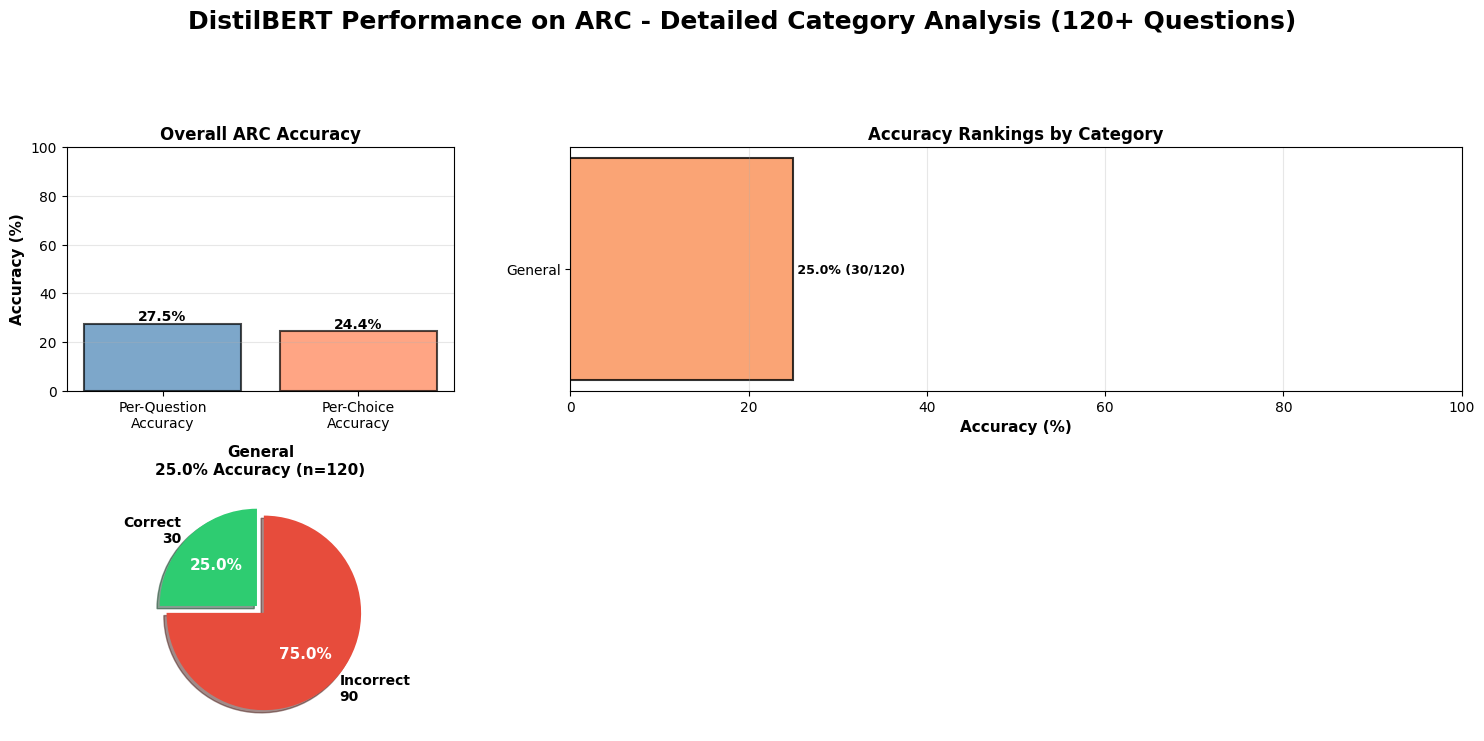


✓ Detailed Visualization complete!


In [20]:
# Create detailed visualizations for ARC benchmark results with individual category plots
# Prepare category data
categories_list = []
accuracies_list = []
correct_counts = []
total_counts = []

for category, stats in sorted(benchmark_results['Category Accuracies'].items()):
    if stats['total'] > 0:
        categories_list.append(category)
        acc = (stats['correct'] / stats['total']) * 100
        accuracies_list.append(acc)
        correct_counts.append(stats['correct'])
        total_counts.append(stats['total'])

num_categories = len(categories_list)
num_cols = 3
num_rows = (num_categories + num_cols - 1) // num_cols + 2  # +2 for overall plots

fig = plt.figure(figsize=(18, 4 * num_rows))
gs = fig.add_gridspec(num_rows, num_cols, hspace=0.4, wspace=0.3)

fig.suptitle("DistilBERT Performance on ARC - Detailed Category Analysis (120+ Questions)",
             fontsize=18, fontweight="bold", y=0.995)

# Plot 1: Overall Accuracy (top-left)
ax_overall = fig.add_subplot(gs[0, 0])
overall_accs = [benchmark_results['Accuracy (per question)'] * 100,
                benchmark_results['Accuracy (per choice)'] * 100]
colors_overall = ['steelblue', 'coral']
bars_overall = ax_overall.bar(['Per-Question\nAccuracy', 'Per-Choice\nAccuracy'], overall_accs,
                              color=colors_overall, alpha=0.7, edgecolor='black', linewidth=1.5)
ax_overall.set_ylabel('Accuracy (%)', fontsize=11, fontweight="bold")
ax_overall.set_title('Overall ARC Accuracy', fontsize=12, fontweight="bold")
ax_overall.set_ylim([0, 100])
ax_overall.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars_overall, overall_accs):
    height = bar.get_height()
    ax_overall.text(bar.get_x() + bar.get_width()/2., height, f'{acc:.1f}%',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: Category Accuracies Overview (top-middle and top-right)
ax_overview = fig.add_subplot(gs[0, 1:])
if categories_list:
    colors_cat = plt.cm.RdYlGn(np.array(accuracies_list) / 100.0)
    bars_overview = ax_overview.barh(range(len(categories_list)), accuracies_list,
                                     color=colors_cat, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax_overview.set_xlabel('Accuracy (%)', fontsize=11, fontweight="bold")
    ax_overview.set_title('Accuracy Rankings by Category', fontsize=12, fontweight="bold")
    ax_overview.set_yticks(range(len(categories_list)))
    ax_overview.set_yticklabels(categories_list)
    ax_overview.set_xlim([0, 100])
    ax_overview.grid(True, alpha=0.3, axis='x')

    # Add value labels
    for i, (bar, acc, correct, total) in enumerate(zip(bars_overview, accuracies_list, correct_counts, total_counts)):
        width = bar.get_width()
        ax_overview.text(width, bar.get_y() + bar.get_height()/2.,
                        f' {acc:.1f}% ({correct}/{total})',
                        ha='left', va='center', fontsize=9, fontweight='bold')
else:
    ax_overview.text(0.5, 0.5, 'No category data available',
                    ha='center', va='center', transform=ax_overview.transAxes, fontsize=12)
    ax_overview.axis('off')

# Plot individual category plots
for idx, (category, accuracy, correct, total) in enumerate(zip(categories_list, accuracies_list, correct_counts, total_counts)):
    row = 1 + (idx // num_cols)
    col = idx % num_cols
    ax = fig.add_subplot(gs[row, col])

    # Create detailed data for this category
    correct_pct = accuracy
    incorrect_pct = 100 - accuracy

    # Pie chart for correct/incorrect
    sizes = [correct, total - correct]
    labels = [f'Correct\n{correct}', f'Incorrect\n{total - correct}']
    colors_pie = ['#2ecc71', '#e74c3c']
    explode = (0.05, 0.05)

    wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
                                        autopct='%1.1f%%', shadow=True, startangle=90,
                                        textprops={'fontsize': 10, 'weight': 'bold'})

    # Make percentage text more visible
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(11)
        autotext.set_weight('bold')

    # Title with category and stats
    ax.set_title(f'{category}\n{correct_pct:.1f}% Accuracy (n={total})',
                fontsize=11, fontweight="bold", pad=10)

plt.show()

print("\n✓ Detailed Visualization complete!")

## About This Benchmark

### What is ARC?
The **AI2 Reasoning Challenge** (ARC) is a benchmark containing science exam questions from 3rd to 9th grade. Questions span:
- **Physics**: Motion, Forces, Energy
- **Chemistry**: Elements, Reactions, Matter
- **Biology**: Life Processes, Genetics, Ecosystems
- **Earth Science**: Weather, Geology, Astronomy
- **General Science**: Problem-Solving, Analysis

### Dataset Details
- **ARC-Easy**: 2,590 questions (easier difficulty)
- **ARC-Challenge**: 1,119 questions (harder difficulty)
- **Format**: Multiple choice with 4 answer options (A, B, C, D)
- **This Benchmark**: Uses 15 Easy + 15 Challenge questions for quick testing

### How This Benchmark Works
1. Each question-answer pair is evaluated separately
2. Model predicts confidence for each choice being correct
3. Highest confidence choice is selected as the answer
4. Accuracy is calculated against ground truth labels

### Note on DistilBERT
- DistilBERT was trained on **sequence classification** tasks (like sentiment analysis)
- It's **not specifically trained** for science QA or ARC
- This benchmark shows general reasoning and knowledge retention capabilities
- For better ARC performance, consider fine-tuning or using a QA-specialized model

### How to Use in Google Colab
1. Open [Google Colab](https://colab.research.google.com)
2. Go to **Runtime → Change runtime type → GPU (T4)**
3. Upload this notebook
4. Run all cells: **Runtime → Run all**
5. View accuracy results and performance metrics

### Customization
To use more ARC questions, modify line in "Load ARC Dataset" cell:
```python
arc_easy = load_dataset("ai2_arc", "ARC-Easy", split="test", trust_remote_code=True)[:N]  # Change N
arc_challenge = load_dataset("ai2_arc", "ARC-Challenge", split="test", trust_remote_code=True)[:N]  # Change N
```

### Tips for Better Results
- **Fine-tuning**: Train the model on ARC questions for better accuracy
- **Larger models**: Try RoBERTa or ALBERT for improved reasoning
- **Ensemble**: Combine multiple models for better predictions
- **Prompt engineering**: Reformulate questions to improve understanding